# **Vorhersage von Benutzer Zufriedenheit**

## Ziel:
ist es mit dem gegebenen Datensatz die Zufriedenheit der Kunden vorauszusagen und dabei wichtige Attribute herauszufinden.

### Probelemtyp:




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## **Setup**

In [2]:
drive.mount('/content/drive')
data_path = "/content/drive/MyDrive/Python Projects/Airline Satisfaction/airlines_final.csv"
airlines = pd.read_csv(data_path, index_col=0)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **Data Understanding**

In [3]:
airlines.head(15)

,id,day,airline,destination,dest_region,dest_size,boarding_area,dept_time,wait_min,cleanliness,safety,satisfaction
0,1351,Tuesday,UNITED INTL,KANSAI,Asia,Hub,Gates 91-102,2018-12-31,115.0,Clean,Neutral,Very satisfied
1,373,Friday,ALASKA,SAN JOSE DEL CABO,Canada/Mexico,Small,Gates 50-59,2018-12-31,135.0,Clean,Very safe,Very satisfied
2,2820,Thursday,DELTA,LOS ANGELES,West US,Hub,Gates 40-48,2018-12-31,70.0,Average,Somewhat safe,Neutral
3,1157,Tuesday,SOUTHWEST,LOS ANGELES,West US,Hub,Gates 20-39,2018-12-31,190.0,Clean,Very safe,Somewhat satsified
4,2992,Wednesday,AMERICAN,MIAMI,East US,Hub,Gates 50-59,2018-12-31,559.0,Somewhat clean,Very safe,Somewhat satsified
5,634,Thursday,ALASKA,NEWARK,East US,Hub,Gates 50-59,2018-12-31,140.0,Somewhat clean,Very safe,Very satisfied
6,2578,Saturday,JETBLUE,LONG BEACH,West US,Small,Gates 1-12,2018-12-31,63.0,Clean,Very safe,Somewhat satsified
8,2592,Saturday,AEROMEXICO,MEXICO CITY,Canada/Mexico,Hub,Gates 1-12,2018-12-31,215.0,Somewhat clean,Very safe,Neutral
9,919,Friday,AIR CANADA,TORONTO,Canada/Mexico,Hub,Gates 91-102,2018-12-31,70.0,Somewhat clean,Somewhat safe,Somewhat satsified
10,3028,Tuesday,UNITED,PORTLAND,West US,Medium,Gates 70-90,2018-12-31,180.0,Average,Very safe,Neutral


In [4]:
airlines.describe()

,id,wait_min
count,2477.000000,2477.000000
mean,1813.363746,166.084376
std,945.226305,107.643625
min,1.000000,15.000000
25%,1038.000000,105.000000
50%,1859.000000,145.000000
75%,2581.000000,185.000000
max,9004.000000,1365.000000


In [5]:
print(airlines.columns)

Index(['id', 'day', 'airline', 'destination', 'dest_region', 'dest_size',
       'boarding_area', 'dept_time', 'wait_min', 'cleanliness', 'safety',
       'satisfaction'],
      dtype='object')


Wichtig ist, dass wir einen Überblick haben, um welche Skaleneinheit es sich hier handelt, um gegebenfalls in der "Data Preparation" die Attribute anpassen.


| Attribut       | Beschreibung                              | Skalenniveau |
|----------------|--------------------------------------------|--------------|
| ID             | Eindeutige Identifikationsnummer           | Nominal      |
| Day            | Wochentag des Fluges                       | Nominal      |
| Airline        | Fluggesellschaft                           | Nominal      |
| Destination    | Zielflughafen / Zielstadt                  | Nominal      |
| Dest_Region    | Region des Zielflughafens                  | Nominal      |
| Dest_Size      | Größe des Zielflughafens                   | Ordinal      |
| Boarding Area  | Zugewiesener Boarding-Bereich              | Nominal      |
| dept_time      | Wartezeit in Minuten                       | Intervall    |
| Wait_min       | Wartezeit in Minuten                       | Verhältnis   |
| Cleanliness    | Bewertung der Sauberkeit (Skala)           | Ordinal      |
| Safety         | Bewertung des Sicherheitsgefühls (Skala)   | Ordinal      |
| Satisfaction   | Gesamtzufriedenheit (Skala)                | Ordinal      |

In [6]:
# Wir müssen schauen, wie die Verteilung der Werte im Zielattribut "Satisfaction"
airlines['satisfaction'].value_counts()

,count
satisfaction,
Somewhat satsified,1349
Very satisfied,596
Neutral,486
Somewhat unsatisfied,42
Very unsatisfied,4


Man kann eindeutig erkennen, dass der Datensatz "unbalanced" ist, was später wichtig bei der Modellauswahl ist.

## **Data Preparation**


### Fehlende Werte

In [7]:
print(airlines.isna().sum())

id               0
day              0
airline          0
destination      0
dest_region      0
dest_size        0
boarding_area    0
dept_time        0
wait_min         0
cleanliness      0
safety           0
satisfaction     0
dtype: int64


### Inkonsistente Kategorien
In manchen Spalten sind die Werte nicht alle gleich

In [8]:
for i in range(len(airlines.columns)):
  print(airlines.iloc[:,i].unique(), "\n")

[1351  373 2820 ... 2684 2549 2162] 

['Tuesday' 'Friday' 'Thursday' 'Wednesday' 'Saturday' 'Sunday' 'Monday'] 

['UNITED INTL' 'ALASKA' 'DELTA' 'SOUTHWEST' 'AMERICAN' 'JETBLUE'
 'AEROMEXICO' 'AIR CANADA' 'UNITED' 'INTERJET' 'TURKISH AIRLINES'
 'AIR FRANCE/KLM' 'HAWAIIAN AIR' 'COPA' 'WOW' 'KOREAN AIR' 'EMIRATES'
 'AVIANCA' 'AER LINGUS' 'CATHAY PACIFIC' 'BRITISH AIRWAYS'
 'PHILIPPINE AIRLINES' 'LUFTHANSA' 'QANTAS' 'FRONTIER' 'CHINA EASTERN'
 'EVA AIR' 'VIRGIN ATLANTIC' 'AIR NEW ZEALAND' 'SINGAPORE AIRLINES'
 'AIR CHINA' 'CHINA SOUTHERN' 'ANA ALL NIPPON'] 

['KANSAI' 'SAN JOSE DEL CABO' 'LOS ANGELES' 'MIAMI' 'NEWARK' 'LONG BEACH'
 'MEXICO CITY' 'TORONTO' 'PORTLAND' 'SAN DIEGO' 'BOSTON' 'SPOKANE'
 'GUADALAJARA' 'MINNEAPOLIS-ST. PAUL' 'NEW YORK-JFK' 'ISTANBUL'
 'BALTIMORE' 'LAS VEGAS' 'SHANGHAI' 'TOKYO-NARITA' 'PARIS-DE GAULLE'
 'HONOLULU' 'DALLAS-FT. WORTH' 'PANAMA CITY' 'PHOENIX' 'REYKJAVIK'
 'SAN ANTONIO' 'HONG KONG' 'SEOUL' 'DUBAI' "CHICAGO-O'HARE" 'INDIANAPOLIS'
 'SAN SALVADOR' 'SALT 

Man kann erkennen, dass zu Beispiel in der Spalte "dest_regio" "eur" und "Europe" vorkommen, was in konsistenz ist. Dies müssen wir nun anpassen.

In [9]:
# wir ändern die Region alle zu einem lower case Wort und passen 'eur' an
airlines['dest_region'] = airlines['dest_region'].str.lower()
airlines['dest_region'] = airlines['dest_region'].replace({'eur':'europe'})
airlines['satisfaction'] = airlines['satisfaction'].replace({'Somewhat satsified':'Somewhat satisfied'})

# Leerzeichen entfernen
airlines['dest_size'] = airlines['dest_size'].str.strip()

# überprüfen der Änderungen
print(airlines['dest_region'].unique())
print(airlines['dest_size'].unique())
print(airlines['satisfaction'].unique())

['asia' 'canada/mexico' 'west us' 'east us' 'midwest us' 'middle east'
 'europe' 'central/south america' 'australia/new zealand']
['Hub' 'Small' 'Medium' 'Large']
['Very satisfied' 'Neutral' 'Somewhat satisfied' 'Somewhat unsatisfied'
 'Very unsatisfied']


### Feature Engineering


#### Feature Creation


In [10]:
wait_ranges = [0, 60, 180, np.inf]
wait_names = ["short", "medium", "long"]

airlines['wait_type'] = pd.cut(airlines['wait_min'], bins = wait_ranges, labels = wait_names)


mapping = {"Monday":"weekday", "Tuesday":"weekday", "Wednesday":"weekday", "Thursday":"weekday", "Friday": "weekday", "Saturday":"weekend", "Sunday":"weekend"}
airlines['day_week'] = airlines['day'].replace(mapping)

print(airlines['wait_type'].unique(), "\n")
print(airlines['day_week'].unique(), "\n")

['medium', 'long', 'short']
Categories (3, object): ['short' < 'medium' < 'long'] 

['weekday' 'weekend'] 



#### Feature Selection


In [11]:
print(airlines.head())

     id        day      airline        destination    dest_region dest_size  \
0  1351    Tuesday  UNITED INTL             KANSAI           asia       Hub   
1   373     Friday       ALASKA  SAN JOSE DEL CABO  canada/mexico     Small   
2  2820   Thursday        DELTA        LOS ANGELES        west us       Hub   
3  1157    Tuesday    SOUTHWEST        LOS ANGELES        west us       Hub   
4  2992  Wednesday     AMERICAN              MIAMI        east us       Hub   

  boarding_area   dept_time  wait_min     cleanliness         safety  \
0  Gates 91-102  2018-12-31     115.0           Clean        Neutral   
1   Gates 50-59  2018-12-31     135.0           Clean      Very safe   
2   Gates 40-48  2018-12-31      70.0         Average  Somewhat safe   
3   Gates 20-39  2018-12-31     190.0           Clean      Very safe   
4   Gates 50-59  2018-12-31     559.0  Somewhat clean      Very safe   

         satisfaction wait_type day_week  
0      Very satisfied    medium  weekday  
1     

In [12]:
airlines = airlines.drop(columns='id', axis=1)
airlines = airlines.drop(columns='day', axis=1)
airlines = airlines.drop(columns='destination', axis=1)
airlines = airlines.drop(columns='boarding_area', axis=1)
airlines = airlines.drop(columns='dept_time', axis=1)
airlines = airlines.drop(columns='wait_min', axis=1)

# verifizieren des Data Frames
print(airlines.head())

       airline    dest_region dest_size     cleanliness         safety  \
0  UNITED INTL           asia       Hub           Clean        Neutral   
1       ALASKA  canada/mexico     Small           Clean      Very safe   
2        DELTA        west us       Hub         Average  Somewhat safe   
3    SOUTHWEST        west us       Hub           Clean      Very safe   
4     AMERICAN        east us       Hub  Somewhat clean      Very safe   

         satisfaction wait_type day_week  
0      Very satisfied    medium  weekday  
1      Very satisfied    medium  weekday  
2             Neutral    medium  weekday  
3  Somewhat satisfied      long  weekday  
4  Somewhat satisfied      long  weekday  


#### Feature Encoding

In [13]:
from sklearn.preprocessing import OrdinalEncoder

# Ordinal Encoding
dest_size_order = [['Small', 'Medium','Large', 'Hub']]
cleanliness_order = [['Dirty','Somewhat dirty','Average', 'Somewhat clean', 'Clean']]
safety_order = [['Very unsafe','Somewhat unsafe','Neutral', 'Somewhat safe', 'Very safe']]
wait_order = [['short', 'medium', 'long']]

enc = OrdinalEncoder(categories=dest_size_order + cleanliness_order + safety_order + wait_order)
airlines[['dest_size', 'cleanliness', 'safety', 'wait_type']] = enc.fit_transform(airlines[['dest_size', 'cleanliness', 'safety', 'wait_type']])
print(airlines.head(),"\n")

#airlines_dummies = pd.get_dummies(airlines,columns=['airline', 'dest_region', 'day_week'],drop_first=True)
#print(airlines_dummies.head())

       airline    dest_region  dest_size  cleanliness  safety  \
0  UNITED INTL           asia        3.0          4.0     2.0   
1       ALASKA  canada/mexico        0.0          4.0     4.0   
2        DELTA        west us        3.0          2.0     3.0   
3    SOUTHWEST        west us        3.0          4.0     4.0   
4     AMERICAN        east us        3.0          3.0     4.0   

         satisfaction  wait_type day_week  
0      Very satisfied        1.0  weekday  
1      Very satisfied        1.0  weekday  
2             Neutral        1.0  weekday  
3  Somewhat satisfied        2.0  weekday  
4  Somewhat satisfied        2.0  weekday   



## **Modeling**

### Train und Test Set

In [14]:
# für Logistic Regression gibt es der Scope des Zielattributes anders
airlines_copy = airlines.copy()
satisfied_mapping = {"Very satisfied": "satisfied", "Somewhat satisfied": "satisfied", "Neutral": "unsatisfied", "Somewhat unsatisfied": "unsatisfied", "Very unsatisfied": "unsatisfied"}
airlines_copy['new_satisfaction'] = airlines_copy['satisfaction'].replace(satisfied_mapping)

airlines_copy = airlines_copy.drop(columns='satisfaction', axis=1)

print(airlines_copy.head(15))

airlines_copy = pd.get_dummies(airlines_copy,columns=['airline', 'dest_region', 'day_week'],drop_first=True)


X = airlines_copy.drop('new_satisfaction', axis=1)
y = airlines_copy['new_satisfaction'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

        airline    dest_region  dest_size  cleanliness  safety  wait_type  \
0   UNITED INTL           asia        3.0          4.0     2.0        1.0   
1        ALASKA  canada/mexico        0.0          4.0     4.0        1.0   
2         DELTA        west us        3.0          2.0     3.0        1.0   
3     SOUTHWEST        west us        3.0          4.0     4.0        2.0   
4      AMERICAN        east us        3.0          3.0     4.0        2.0   
5        ALASKA        east us        3.0          3.0     4.0        1.0   
6       JETBLUE        west us        0.0          4.0     4.0        1.0   
8    AEROMEXICO  canada/mexico        3.0          3.0     4.0        2.0   
9    AIR CANADA  canada/mexico        3.0          3.0     3.0        1.0   
10       UNITED        west us        1.0          2.0     4.0        1.0   
11    SOUTHWEST        west us        1.0          4.0     4.0        2.0   
12      JETBLUE        east us        2.0          3.0     4.0        2.0   

### KFold

LogisticRegression: [0.72205438 0.72121212 0.69090909 0.73333333 0.6969697  0.72121212]
RandomForestClassifier: [0.6858006  0.72727273 0.77878788 0.73636364 0.75454545 0.73636364]
KNeighborsClassifier: [0.77945619 0.77575758 0.79393939 0.79090909 0.80606061 0.76969697]


/tmp/ipykernel_55751/3475348787.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(results, labels=models.keys())


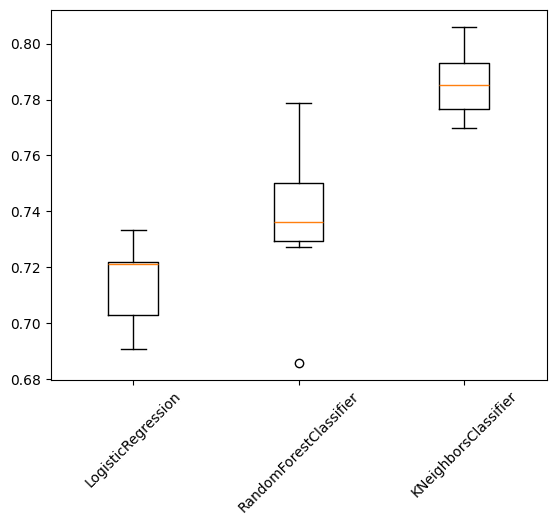

In [15]:
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

logreg = LogisticRegression(class_weight='balanced')
rf = RandomForestClassifier(class_weight='balanced')
knn = KNeighborsClassifier()

models = {
    "LogisticRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", logreg)
        ]),

    "RandomForestClassifier": Pipeline([("model", rf)]),

    "KNeighborsClassifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", knn)
        ])
}

results = []

kf = KFold(n_splits=6, random_state=12, shuffle=True)

for name, model in models.items():
    cv_results = cross_val_score(model, X_train, y_train, cv=kf)
    print(f"{name}: {cv_results}")
    results.append(cv_results)
plt.boxplot(results, labels=models.keys())
plt.xticks(rotation=45)
plt.show()

### Hyper Parameter Tuning

In [16]:
from sklearn.model_selection import GridSearchCV

params = [{
    'n_neighbors':np.arange(1, 30),
    'weights':['uniform', 'distance'],
    'algorithm': ['auto', 'ball_tree'],
    'leaf_size': [20,30,40],
}]

cv = GridSearchCV(knn,
                  param_grid=params,
                  cv=2,
                  scoring="accuracy")

cv.fit(X_train, y_train)
y_pred = cv.predict(X_test)
print(cv.best_score_)
print(cv.best_params_)

0.7995958576685116
{'algorithm': 'ball_tree', 'leaf_size': 40, 'n_neighbors': np.int64(25), 'weights': 'uniform'}


In [17]:
# Werte weiter einschränken
params2 = [{
    'n_neighbors':range(20, 30),
    'leaf_size':range(35,45)
}]

cv2 = GridSearchCV(knn,
                  param_grid=params2,
                  cv=2,
                  scoring="accuracy")

cv2.fit(X_train, y_train)
y_pred = cv2.predict(X_test)
print(cv2.best_score_)
print(cv2.best_params_)

0.7975741267365889
{'leaf_size': 35, 'n_neighbors': 21}


## **Evaluation**

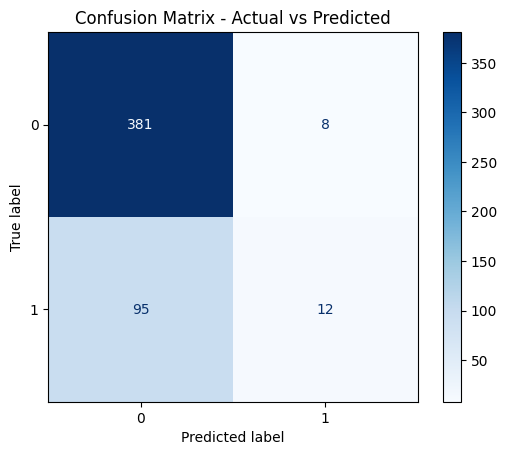

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap='Blues')

plt.title("Confusion Matrix - Actual vs Predicted")

plt.show()

In [19]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

   satisfied       0.80      0.98      0.88       389
 unsatisfied       0.60      0.11      0.19       107

    accuracy                           0.79       496
   macro avg       0.70      0.55      0.53       496
weighted avg       0.76      0.79      0.73       496



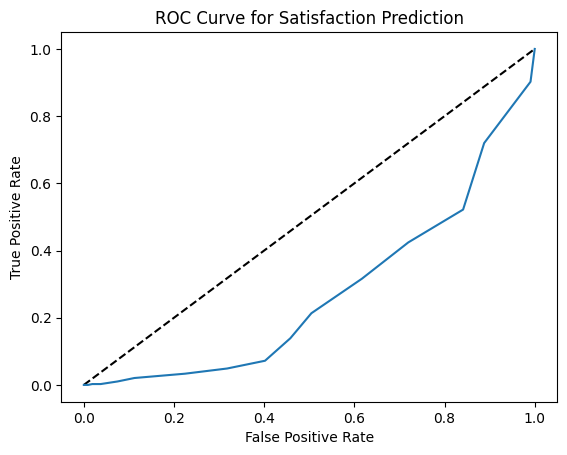

In [20]:
from sklearn.metrics import  roc_curve

y_test = np.where(y_test == 'satisfied', 1, 0)

y_proba = cv2.predict_proba(X_test)[:, 1]

# Generate ROC curve values: fpr, tpr, thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.plot([0, 1], [0, 1], 'k--')

# Plot tpr against fpr
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Satisfaction Prediction')
plt.show()

## **Schlussfolgerung**

Das tranierte Modell zeigt auf den ersten Blick eine gute accuracy von ungefähr 79%, was zunächst einen positiven Eindruck vermittelt. Eine genauere Analyse der Metriken zeigt jedoch, dass diese Genauigkeit starkt durch die Mehrheitsklasse beeinflusst wird.

Das Modell ist inder Lage, zufriedene Kunden sehr zuverlässig zu erkennen, versagt jedoch weitgehend bei der Identifikation unzufriedener Kunden. Die bedeutet, dass ein Großteil der kritischen Fälle nicht erkannt wird.

Auch die ROC kurve bestätigt diese Schwäche, da sie nur eine geringe Trennschärfe zeigt und nahe an der Zufallslienie verläuft

Die Hauptursache für dieses Verhalten liegt in der unausgeglichenen Klassenverteilung. Da Modellt lernt überwiegend die dominante Klasse und vernachlässigt die Minderheitsklasse.

Zur Verbesserung des Modells sollte folgende Maßnahmen ergriffen werden:
1. Sammlung zusätzlicher Daten (inbesondere der Minderheitsklassen)
2. Anwendung von Techniken zur Balancierung der Daten (hier z.B. Oversampling)